#Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Read Data

In [3]:
df = pd.read_excel("https://raw.github.com/dewitrilestari/BLKPP-DIY-VS-CODE/main/Final%20Project/Data/Raw/association_rules.xlsx")

In [4]:
df

,invoice_code,stock_code,description,quantity,order_date,price,unit,customer_id,country,price_rupiah,...,month,year,revenue,day_of_week,is_weekend,hour_transaction,quantity_category,segment_rfm,basket_size,product_category
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,dollar,17850.0,United Kingdom,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,dollar,17850.0,United Kingdom,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,dollar,17850.0,United Kingdom,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,dollar,17850.0,United Kingdom,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,dollar,17850.0,United Kingdom,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,dollar,12680.0,France,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,dollar,12680.0,France,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,dollar,12680.0,France,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,dollar,12680.0,France,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Kolom Asli:
1. invoice_code: a 6-digit integral number uniquely assigned to each transaction. If this code starts with letter 'c', it indicates a cancellation
2. stock_code: a 5/6-digit integral number uniquely assigned to each distinct product
3. description: product name
4. quantity: the quantities of each product (item) per transaction
5. order_date: the day and time when each transaction was generated
6. price: product price per unit
7. dollar: USD currency code
8. customer_id: a 5-digit integral number uniquely assigned to each customer
9. country: the name of the country where each customer resides

Feature Engineering:
1. price_rupiah: harga dalam rupiah rata-rata dari bulan Desember 2010 - Desember 2011 (Rp 8.790,00)
2. date
3. month
4. year
5. revenue
6. day_of_week: hari dalam minggu (1-7)
7. is_weekend: sabtu/minggu (0/1)
8. hour_transaction
9. quantity_category: mengkategorikan kuantitas
10. segmen_rfm
11. basket_size: dari association rules
12. product_category

Berisi data transaksi pelanggan dari tanggal 1 Desember 2010 hingga 9 Desember 2011 untuk perusahaan ritel online yang berbasis di Inggris. Perusahaan ini menjual barang-barang unik untuk hadiah. Pelanggan didominasi oleh pedagang grosir.

#Tipe Data

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   invoice_code       541910 non-null  object        
 1   stock_code         541910 non-null  object        
 2   description        540456 non-null  object        
 3   quantity           541910 non-null  int64         
 4   order_date         541910 non-null  datetime64[ns]
 5   price              541910 non-null  float64       
 6   unit               541910 non-null  object        
 7   customer_id        406830 non-null  float64       
 8   country            541910 non-null  object        
 9   price_rupiah       0 non-null       float64       
 10  date               0 non-null       float64       
 11  month              0 non-null       float64       
 12  year               0 non-null       float64       
 13  revenue            0 non-null       float64 

1. order_date diubah ke datetime
2. customer_id diubah ke integer

#Statistika Dasar

In [6]:
df.describe()

,quantity,order_date,price,customer_id,price_rupiah,date,month,year,revenue,day_of_week,is_weekend,hour_transaction,quantity_category,segment_rfm,basket_size,product_category
count,541910.000000,541910,541910.000000,406830.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,9.552234,2011-07-04 13:35:22.342307584,4.611138,15287.684160,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,218.080957,NaN,96.759765,1713.603074,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#Missing Values

In [7]:
df.isnull().sum()

,0
invoice_code,0
stock_code,0
description,1454
quantity,0
order_date,0
price,0
unit,0
customer_id,135080
country,0
price_rupiah,541910


1. kolom description memiliki missing values sebanyak 1.454
2. kolom customer_id memiliki missing values sebanyak 135.080

#Duplicate Checking

In [8]:
df.duplicated().sum()

np.int64(5268)

1. sebanyak 5268 baris yang duplikat

In [9]:
# Menampilkan semua baris yang duplikat, diurutkan agar yang duplikat berdekatan
duplicate_rows = df[df.duplicated(keep=False)].sort_values(by=['invoice_code', 'stock_code'])

# Tampilkan 10 baris pertama
duplicate_rows.head(10)

,invoice_code,stock_code,description,quantity,order_date,price,unit,customer_id,country,price_rupiah,...,month,year,revenue,day_of_week,is_weekend,hour_transaction,quantity_category,segment_rfm,basket_size,product_category
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,dollar,17908.0,United Kingdom,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,dollar,17908.0,United Kingdom,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,dollar,17908.0,United Kingdom,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,dollar,17908.0,United Kingdom,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,dollar,17908.0,United Kingdom,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,dollar,17908.0,United Kingdom,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,dollar,17908.0,United Kingdom,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,dollar,17908.0,United Kingdom,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
565,536412,21448,12 DAISY PEGS IN WOOD BOX,2,2010-12-01 11:49:00,1.65,dollar,17920.0,United Kingdom,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
578,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,dollar,17920.0,United Kingdom,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# Menghapus duplikat
df.drop_duplicates(inplace=True)

# Cek ulang untuk memastikan hasilnya 0
print(df.duplicated().sum())

0


In [11]:
df.isnull().sum()

,0
invoice_code,0
stock_code,0
description,1454
quantity,0
order_date,0
price,0
unit,0
customer_id,135037
country,0
price_rupiah,536642


1.  Baris data berkurang sebanyak 5.268 atau 0,97% dari total data, dari 541.910 menjadi 536.642

#Cancelled Orders Checking

In [12]:
# Memastikan tipe data berupa string agar proses pencocokan (matching) akurat
df["customer_id"] = df["customer_id"].astype(str)
df["stock_code"] = df["stock_code"].astype(str)
df["invoice_code"] = df["invoice_code"].astype(str)

# Pisahkan menjadi kelompok Order Normal dan Cancellation
# Order normal: quantity positif, invoice_code tidak diawali 'C'
df_normal = df[(df["quantity"] > 0) & (~df["invoice_code"].str.startswith("C", na=False))].copy()

# Cancellation: quantity negatif, invoice_code diawali 'C'
df_cancel = df[(df["quantity"] < 0) & (df["invoice_code"].str.startswith("C", na=False))].copy()

# Mengubah nilai quantity data cancel menjadi positif (absolute) agar bisa di-merge
df_cancel["quantity_absolute"] = df_cancel["quantity"].abs()

# Lakukan Merge untuk mencocokkan pesanan yang di-order lalu di-cancel total
# Kita pasangkan berdasarkan Customer, Produk, dan Jumlah Quantity yang sama
matched_cancellations = pd.merge(
    df_normal,
    df_cancel,
    left_on=["customer_id", "stock_code", "quantity"],
    right_on=["customer_id", "stock_code", "quantity_absolute"],
    suffixes=("_order", "_cancel"),
)

# Tampilkan Hasil Analisis
total_pasangan = len(matched_cancellations)
print(f"=== HASIL DETEKSI TRANSAKSI BATAL ===")
print(f"Ditemukan sebanyak {total_pasangan} baris transaksi yang di-order lalu di-cancel total.\n")

if total_pasangan > 0:
    print("Contoh data yang saling berpasangan (Order vs Cancel):")

    # Kolom tampilan disusun menggunakan nama kolom yang Anda miliki
    # Ditambahkan suffix (_order / _cancel) otomatis oleh pandas akibat proses merge
    kolom_tampilan = [
        "customer_id",
        "stock_code",
        "description_order",      # Mengikuti penulisan kolom Anda 'descrition'
        "invoice_code_order",
        "quantity_order",
        "invoice_code_cancel",
        "quantity_cancel",
    ]

    # Menampilkan 5 sampel teratas
    print(matched_cancellations[kolom_tampilan])
else:
    print("Tidak ditemukan transaksi dengan pola order-cancel yang sama persis.")

=== HASIL DETEKSI TRANSAKSI BATAL ===
Ditemukan sebanyak 11967 baris transaksi yang di-order lalu di-cancel total.

Contoh data yang saling berpasangan (Order vs Cancel):
      customer_id stock_code                   description_order  \
0         17850.0      22632           HAND WARMER RED POLKA DOT   
1         17850.0      22632           HAND WARMER RED POLKA DOT   
2         17850.0      21071      VINTAGE BILLBOARD DRINK ME MUG   
3         17850.0      82483  WOOD 2 DRAWER CABINET WHITE FINISH   
4         17850.0      21071      VINTAGE BILLBOARD DRINK ME MUG   
...           ...        ...                                 ...   
11962     15311.0      21313         GLASS HEART T-LIGHT HOLDER    
11963     15311.0      21313         GLASS HEART T-LIGHT HOLDER    
11964     15311.0      21313         GLASS HEART T-LIGHT HOLDER    
11965     17581.0      22083           PAPER CHAIN KIT RETROSPOT   
11966     15804.0      22178     VICTORIAN GLASS HANGING T-LIGHT   

      invoic

##Handle Cancelled Orders

In [13]:
# Memastikan tipe data berupa string sebelum proses pencocokan
df["customer_id"] = df["customer_id"].astype(str)
df["stock_code"] = df["stock_code"].astype(str)
df["invoice_code"] = df["invoice_code"].astype(str)

# Identifikasi kelompok Order dan Cancel (menggunakan dataframe sementara)
df_normal = df[(df["quantity"] > 0) & (~df["invoice_code"].str.startswith("C", na=False))].copy()
df_cancel = df[(df["quantity"] < 0) & (df["invoice_code"].str.startswith("C", na=False))].copy()
df_cancel["quantity_absolute"] = df_cancel["quantity"].abs()

# Simpan index asli ke kolom temporary
df_normal["original_index"] = df_normal.index
df_cancel["original_index"] = df_cancel.index

# Gabungkan untuk mencari pasangan yang MATCH (Saling Membatalkan)
matched = pd.merge(
    df_normal,
    df_cancel,
    left_on=["customer_id", "stock_code", "quantity"],
    right_on=["customer_id", "stock_code", "quantity_absolute"],
    suffixes=("_order", "_cancel")
)

# =========================================================================
# LOGIKA BARU: MENENTUKAN LIST INDEX YANG HARUS DI-DROP
# =========================================================================

# Ambil index dari transaksi NORMAL yang memiliki pasangan cancel (Hapus)
index_order_berpasangan = matched["original_index_order"].tolist()

# Cari transaksi CANCEL yang TIDAK memiliki pasangan order (Hapus)
index_cancel_semua = df_cancel["original_index"].tolist()
index_cancel_berpasangan = matched["original_index_cancel"].tolist()

# Trik set: Semua index cancel DIKURANGI index cancel yang punya pasangan
index_cancel_tidak_berpasangan = list(set(index_cancel_semua) - set(index_cancel_berpasangan))

# Gabungkan kedua daftar index yang harus dibuang tersebut
index_harus_drop = index_order_berpasangan + index_cancel_tidak_berpasangan

# EKSEKUSI: Hapus langsung dari dataframe utama 'df'
df.drop(index=index_harus_drop, inplace=True)

# CETAK HASIL INVESTIGASI
print(f"1. Transaksi Order Normal (yang dicancel) dihapus : {len(index_order_berpasangan)} baris")
print(f"2. Transaksi Cancel 'Yatim Piatu' (tanpa order) dihapus : {len(index_cancel_tidak_berpasangan)} baris")
print(f"3. Transaksi Cancel yang sah (punya pasangan) berhasil di-KEEP: {len(index_cancel_berpasangan)} baris")
print(f"Sisa baris akhir di dataframe 'df': {len(df)}")

1. Transaksi Order Normal (yang dicancel) dihapus : 11967 baris
2. Transaksi Cancel 'Yatim Piatu' (tanpa order) dihapus : 5661 baris
3. Transaksi Cancel yang sah (punya pasangan) berhasil di-KEEP: 11967 baris
Sisa baris akhir di dataframe 'df': 522673


##Zero and Minus in Quantity and Price

In [14]:
# 1. MENGISI DESCRIPTION YANG KOSONG BERDASARKAN STOCK CODE

# Pastikan data teks tidak memiliki spasi berlebih
df['stock_code'] = df['stock_code'].astype(str).str.strip()

# Deteksi description yang benar-benar kosong (NaN, tulisan 'nan', atau string kosong '')
is_missing_desc = df['description'].isna() | (df['description'].astype(str).str.strip() == '') | (df['description'].astype(str).str.lower() == 'nan')

jumlah_kosong_awal = is_missing_desc.sum()
print(f"🔍 Ditemukan {jumlah_kosong_awal} baris dengan description kosong.")

if jumlah_kosong_awal > 0:
    # Buat "Kamus" / Mapping dari data yang description-nya TIDAK kosong.
    # Kita ambil nama description yang paling sering muncul (mode) untuk setiap stock_code
    print("⏳ Sedang membuat kamus referensi stock_code...")
    referensi_produk = df[~is_missing_desc].groupby('stock_code')['description'].agg(
        lambda x: x.mode()[0] if not x.mode().empty else np.nan
    )

    # Isi description yang kosong menggunakan kamus referensi tadi
    df.loc[is_missing_desc, 'description'] = df.loc[is_missing_desc, 'stock_code'].map(referensi_produk)

    # Cek apakah masih ada yang kosong (Misal: stock_code itu memang belum pernah ada namanya sama sekali di dataset)
    sisa_kosong = df['description'].isna().sum()
    print(f"✅ Berhasil mengisi nama produk! Sisa description kosong sekarang: {sisa_kosong}")

    # Opsional: Jika masih ada sisa karena stock_code-nya benar-benar tidak dikenali sistem
    if sisa_kosong > 0:
        df['description'] = df['description'].fillna("UNKNOWN PRODUCT")
        print("   (Sisa baris yang tidak punya referensi nama diubah menjadi 'UNKNOWN PRODUCT')")

# 2. MENGHAPUS TRANSAKSI NORMAL DENGAN QUANTITY / PRICE <= 0

# Pastikan tipe data numerik
df['quantity'] = pd.to_numeric(df['quantity'], errors='coerce')
df['price'] = pd.to_numeric(df['price'], errors='coerce')

total_awal = len(df)

# Kita buat dua kelompok (masking) kondisi yang BOLEH DISIMPAN (Keep):

# KONDISI 1: Transaksi Cancel (Invoice diawali 'C') -> Apapun isinya, kita SIMPAN
mask_cancel = df['invoice_code'].astype(str).str.startswith("C", na=False)

# KONDISI 2: Transaksi Normal (Bukan 'C') YANG VALID -> Quantity > 0 DAN Price > 0
mask_normal_valid = (~df['invoice_code'].astype(str).str.startswith("C", na=False)) & (df['quantity'] > 0) & (df['price'] > 0)

# EKSEKUSI: Filter dataframe dengan menggabungkan dua kondisi tersebut
# (Artinya: Ambil semua data cancel ATAU data normal yang valid)
df = df[mask_cancel | mask_normal_valid].copy()

total_akhir = len(df)
jumlah_dihapus = total_awal - total_akhir

print(f"🚨 Berhasil menghapus {jumlah_dihapus} baris transaksi normal yang cacat (quantity/price <= 0).")
print(f"📦 Transaksi Cancel (awalan C) tetap dipertahankan dengan aman.")
print(f"📊 Total baris dataframe sekarang: {total_akhir}")

🔍 Ditemukan 1453 baris dengan description kosong.
⏳ Sedang membuat kamus referensi stock_code...
✅ Berhasil mengisi nama produk! Sisa description kosong sekarang: 116
   (Sisa baris yang tidak punya referensi nama diubah menjadi 'UNKNOWN PRODUCT')
🚨 Berhasil menghapus 2499 baris transaksi normal yang cacat (quantity/price <= 0).
📦 Transaksi Cancel (awalan C) tetap dipertahankan dengan aman.
📊 Total baris dataframe sekarang: 520174


#Unique Values in "Invoice Code"

In [15]:
# Mengambil karakter pertama dari setiap invoice_code (pastikan diubah ke string dulu)
df['awalan'] = df['invoice_code'].astype(str).str[0]

# Menampilkan karakter apa saja yang ada di awal beserta jumlahnya
print(df['awalan'].value_counts())

awalan
5    516583
C      3590
A         1
Name: count, dtype: int64


In [16]:
from IPython.display import display

# Memfilter baris yang invoice_code-nya diawali huruf 'A'
baris_unik = df[df['invoice_code'].astype(str).str.startswith('A')]

# Menampilkan dalam bentuk tabel visual yang rapi
display(baris_unik)

,invoice_code,stock_code,description,quantity,order_date,price,unit,customer_id,country,price_rupiah,...,year,revenue,day_of_week,is_weekend,hour_transaction,quantity_category,segment_rfm,basket_size,product_category,awalan
299982,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,dollar,nan,United Kingdom,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A


1. Kolom invoice_code yang memiliki awalan A memiliki description 'Adjust bad dept' dengan customer_id bernilai NaN
2. Apa itu "Bad Debt" (Piutang Macet)?
Bad debt terjadi ketika ada pelanggan (biasanya pembeli grosir/perusahaan yang membeli dengan sistem tempo/kredit) yang tidak bisa membayar tagihan mereka—bisa karena perusahaannya bangkrut, kabur, atau alasan finansial lainnya.
3. Mengapa Ada Kata "Adjust" (Penyesuaian)?
Karena uang tersebut dipastikan tidak akan pernah kembali, bagian akuntansi harus melakukan adjustment (penyesuaian) di dalam sistem untuk menghapus nilai piutang tersebut dari pembukuan agar laporan keuangan akhir perusahaan tetap akurat dan tidak terlihat seolah-olah masih memiliki aset uang di luar.

##Handle Description 'Adjust Bad Debt'

In [17]:
# Menghapus baris yang memiliki deskripsi 'Adjust bad debt'
df = df[df['description'] != 'Adjust bad debt']

In [18]:
df.isnull().sum()

,0
invoice_code,0
stock_code,0
description,0
quantity,0
order_date,0
price,0
unit,0
customer_id,0
country,0
price_rupiah,520173


#Unique Values in Stock Code

In [19]:
# Mencari stock_code yang isinya HANYA huruf (tidak mengandung angka sama sekali)
kode_non_numerik = df[~df['stock_code'].astype(str).str.contains(r'\d', na=False)]

# Tampilkan pasangan kode dan deskripsinya yang unik
print(kode_non_numerik[['stock_code', 'description']].drop_duplicates())

          stock_code                 description
45              POST                     POSTAGE
2239               M                      Manual
4406    BANK CHARGES                Bank Charges
14436              S                     SAMPLES
14514      AMAZONFEE                  AMAZON FEE
40383              m                      Manual
75004            DOT              DOTCOM POSTAGE
84016       DCGSSBOY              BOYS PARTY BAG
84017      DCGSSGIRL             GIRLS PARTY BAG
157195          PADS  PADS TO MATCH ALL CUSHIONS


1. POST & DOT (POSTAGE / DOTCOM POSTAGE): Ini adalah ongkos kirim.
2. M & m (Manual): Input manual oleh staf (bisa berupa koreksi harga atau transaksi luar sistem).
3. BANK CHARGES: Biaya administrasi bank.
4. AMAZONFEE: Biaya komisi atau pendaftaran ke platform Amazon.
5. S (SAMPLES): Barang sampel gratis yang dikirimkan ke mitra, bukan transaksi penjualan retail normal.
6. BOYS PARTY BAG dan GIRLS PARTY BAG: tas bingkisan ulang tahun anak-anak (disimpan).
7. PADS: bantalan/busa untuk sofa atau bantal (disimpan).

In [20]:
# Ambil stock_code unik
unik_kode = pd.Series(df['stock_code'].unique().astype(str))

# Cari kode yang panjangnya kurang dari 5 karakter
kode_pendek = unik_kode[unik_kode.str.len() < 5]

# Intip deskripsi dari kode-kode pendek tersebut
print(df[df['stock_code'].isin(kode_pendek)][['stock_code', 'description']].drop_duplicates())

       stock_code                 description
45           POST                     POSTAGE
2239            M                      Manual
14436           S                     SAMPLES
19975          C2                    CARRIAGE
40383           m                      Manual
75004         DOT              DOTCOM POSTAGE
157195       PADS  PADS TO MATCH ALL CUSHIONS


Kode C2 dengan deskripsi CARRIAGE memiliki arti Biaya Pengangkutan atau Ongkos Kirim (mirip dengan Postage). Istilah carriage biasanya digunakan dalam dunia logistik dan perdagangan untuk mencatat biaya pengiriman barang dari gudang penjual sampai ke tempat pembeli.
Jika tetap dibiarkan di dalam dataset, sistem akan membaca seolah-olah CARRIAGE adalah sebuah barang yang sering dibeli bersamaan dengan produk lain. Ini akan menghasilkan aturan asosiasi (rules) yang tidak ada nilai bisnisnya, seperti: "Jika pelanggan membeli lilin aromaterapi, mereka juga membeli Carriage (Ongkos Kirim)".

In [21]:
# Mencari deskripsi yang mengandung huruf kecil (artinya bukan nama produk standar)
# Pola r'[a-z]' artinya mendeteksi adanya huruf kecil
catatan_manual = df[df['description'].astype(str).str.contains(r'[a-z]', na=False)]

print(catatan_manual[['stock_code', 'description']].drop_duplicates().head(20))

         stock_code                          description
482           21705              BAG 500g SWIRLY MARBLES
918          46000M         POLYESTER FILLER PAD 45x45cm
1963          21704              BAG 250g SWIRLY MARBLES
2038         46000R         POLYESTER FILLER PAD 45x30cm
2039         46000S         POLYESTER FILLER PAD 40x40cm
2068          22686       FRENCH BLUE METAL DOOR SIGN No
2239              M                               Manual
2567          21594        Dr. Jam's Arouzer Stress Ball
3082          21703              BAG 125g SWIRLY MARBLES
3305          22965   3 TRADITIONAl BISCUIT CUTTERS  SET
4406   BANK CHARGES                         Bank Charges
6438         84247K       FOLK ART GREETING CARD,pack/12
11417         18007  ESSENTIAL BALM 3.5g TIN IN ENVELOPE
12561        46000P       POLYESTER FILLER PAD 65CMx65CM
13380         21595           Dad's Cab Electronic Meter
15468         22889         NUMBER TILE VINTAGE FONT No 
20749         21120            

##Handle Unique Values in Stock Code

In [22]:
# Definisikan daftar stock_code operasional yang ingin dibuang
kode_dibuang = ['POST', 'DOT', 'M', 'm', 'BANK CHARGES', 'AMAZONFEE', 'S', 'C2']

# Timpa langsung dataframe 'df' lama kamu dengan hasil data yang sudah bersih
df = df[~df['stock_code'].isin(kode_dibuang)]

# Lakukan pengecekan ulang untuk memastikan kode tersebut sudah musnah dari 'df'
print("--- VERIFIKASI PADA DATAFRAME DF ---")
print(f"Jumlah baris kode operasional yang tersisa di df: {len(df[df['stock_code'].isin(kode_dibuang)])}")

--- VERIFIKASI PADA DATAFRAME DF ---
Jumlah baris kode operasional yang tersisa di df: 0


In [23]:
df.isnull().sum()

,0
invoice_code,0
stock_code,0
description,0
quantity,0
order_date,0
price,0
unit,0
customer_id,0
country,0
price_rupiah,518598


#Voucher in Description

In [24]:
# Membuat daftar nama voucher yang ingin dicari stock_code-nya
daftar_voucher = [
    'Dotcomgiftshop Gift Voucher £40.00',
    'Dotcomgiftshop Gift Voucher £50.00',
    'Dotcomgiftshop Gift Voucher £30.00',
    'Dotcomgiftshop Gift Voucher £20.00',
    'Dotcomgiftshop Gift Voucher £10.00',
    'Dotcomgiftshop Gift Voucher £100.00'
]

# Filter data berdasarkan daftar di atas dan ambil pasangan uniknya
voucher_unik = df[df['description'].isin(daftar_voucher)][['description', 'stock_code','quantity','price']].drop_duplicates()

# Tampilkan hasilnya dalam bentuk tabel yang rapi
display(voucher_unik)

,description,stock_code,quantity,price
38248,Dotcomgiftshop Gift Voucher £40.00,gift_0001_40,1,34.04
42057,Dotcomgiftshop Gift Voucher £50.00,gift_0001_50,1,42.55
44725,Dotcomgiftshop Gift Voucher £30.00,gift_0001_30,1,25.53
44794,Dotcomgiftshop Gift Voucher £20.00,gift_0001_20,1,17.02
55589,Dotcomgiftshop Gift Voucher £20.00,gift_0001_20,1,16.67
94054,Dotcomgiftshop Gift Voucher £30.00,gift_0001_30,1,25.00
112442,Dotcomgiftshop Gift Voucher £10.00,gift_0001_10,1,8.33
145463,Dotcomgiftshop Gift Voucher £40.00,gift_0001_40,1,33.33
161388,Dotcomgiftshop Gift Voucher £20.00,gift_0001_20,2,16.67
178559,Dotcomgiftshop Gift Voucher £50.00,gift_0001_50,1,41.67


1. simpan

#Handle Special Character

In [25]:
# Ubah semua teks menjadi huruf besar agar seragam (menghindari masalah kapitalisasi)
df['description'] = df['description'].astype(str).str.upper()

# Hapus tanda bintang (*)
df['description'] = df['description'].str.replace('*', '', regex=False)

# Hapus tanda titik atau koma yang menggantung di paling akhir kata
df['description'] = df['description'].str.strip('. ,')

# Bersihkan spasi ganda di tengah dan spasi di ujung teks
df['description'] = df['description'].str.replace(r'\s+', ' ', regex=True).str.strip()

In [26]:
# Mengambil semua deskripsi unik dari dataframe (mengabaikan nilai kosong/NaN)
unique_desc = df['description'].dropna().unique()

# Membuat dataframe baru khusus untuk list deskripsi
df_audit = pd.DataFrame(unique_desc, columns=['Original Description'])

# Menambahkan kolom kosong agar nanti Anda mudah memberikan catatan/kategori
df_audit['Kategori (Produk / Bukan)'] = ""
df_audit['Catatan / Anomali'] = ""

# Menyimpan ke dalam file Excel
nama_file = "Daftar_Deskripsi_Unik.xlsx"
df_audit.to_excel(nama_file, index=False)

# Cetak konfirmasi
print(f"✅ Selesai! File '{nama_file}' berhasil dibuat.")
print(f"Total deskripsi unik yang diekstrak: {len(unique_desc)} baris.")

✅ Selesai! File 'Daftar_Deskripsi_Unik.xlsx' berhasil dibuat.
Total deskripsi unik yang diekstrak: 3996 baris.


##Erase Unnecessary Description

In [27]:
# Masukkan semua hasil temuan Anda dan teman Anda ke dalam sebuah list
daftar_sampah = [
    "?", "??", "???", "? SOLD AS SETS?", "?DISPLAY?", "?LOST", "?MISSING",
    "?SOLD AS SETS?", "?? MISSING", "??MISSING", "???LOST", "???MISSING",
    "????DAMAGES????", "????MISSING", "20713", "20713 WRONGLY MARKED",
    "ADD STOCK TO ALLOCATE ONLINE ORDERS", "ADJUST", "ADJUSTMENT",
    "ALLOCATE STOCK FOR DOTCOM ORDERS TA", "AMAZON", "AMAZON ADJUST",
    "AMAZON ADJUSTMENT", "AMAZON SALES", "AMAZON SOLD SETS", "BARCODE PROBLEM",
    "BREAKAGES", "BROKEN", "CAME CODED AS 20713", "CAN'T FIND", "CHECK",
    "CHECK?", "CODE MIX UP? 84930", "COUNTED", "CRACKED", "CRUSHED",
    "CRUSHED BOXES", "CRUSHED CTN", "DAGAMED", "DAMAGED", "DAMAGED STOCK",
    "DAMAGES", "DAMAGES WAX", "DAMAGES?", "DAMAGES/CREDITS FROM ASOS",
    "DAMAGES/DISPLAY", "DAMAGES/DOTCOM?", "DAMAGES/SAMPLES", "DAMAGES/SHOWROOM ETC",
    "DID A CREDIT AND DID NOT TICK RET", "DISPLAY", "DOTCOM", "DOTCOM ADJUST",
    "DOTCOM SALES", "DOTCOM SET", "DOTCOM SOLD IN 6'S", "DOTCOM SOLD SETS",
    "DOTCOM STOCK", "DOTCOMSTOCK", "EBAY", "FAULTY", "FBA", "FOR ONLINE RETAIL ORDERS", "FOUND", "FOUND BOX",
    "FOUND BY JACKIE", "FOUND IN W/HSE", "FOUND SOME MORE ON SHELF", "GIVEN AWAY",
    "HAD BEEN PUT ASIDE", "HISTORIC COMPUTER DIFFERENCE?....SE", "INCORRECT STOCK ENTRY",
    "INCORRECTLY CREDITED C550456 SEE 47", "INCORRECTLY MADE-THROWN AWAY",
    "INCORRECTLY PUT BACK INTO STOCK", "JOHN LEWIS", "LOST", "LOST IN SPACE",
    "LOST??", "MAILOUT", "MARKED AS 23343", "MERCHANT CHANDLER CREDIT ERROR, STO",
    "MIA", "MICHEL OOPS", "MISSING", "MISSING?", "MIX UP WITH C", "MIXED UP",
    "MOULDY", "MOULDY, THROWN AWAY", "MOULDY, UNSALEABLE", "MYSTERY! ONLY EVER IMPORTED 1800",
    "NAN", "NEXT DAY CARRIAGE", "NOT RCVD IN 10/11/2010 DELIVERY", "ON CARGO ORDER",
    "OOPS ! ADJUSTMENT", "PACKING CHARGE", "POSSIBLE DAMAGES OR LOST?",
    "PRINTING SMUDGES/THROWN AWAY", "RCVD BE AIR TEMP FIX FOR DOTCOM SIT",
    "RE DOTCOM QUICK FIX", "RE-ADJUSTMENT", "RETURNED", "REVERSE PREVIOUS ADJUSTMENT",
    "RUSTY THROW AWAY", "RUSTY THROWN AWAY", "SALE ERROR", "SAMPLES",
    "SAMPLES/DAMAGED", "SAMPLES/DAMAGES", "SHOW SAMPLES", "SHOWROOM", "SMASHED",
    "SOLD AS 1", "SOLD AS 1 ON DOTCOM", "SOLD AS 22467", "SOLD AS SET BY DOTCOM",
    "SOLD AS SET ON DOTCOM AND AMAZON", "SOLD AS SET/6 BY DOTCOM", "SOLD IN SET?",
    "SOLD WITH WRONG BARCODE", "STOCK CHECK", "STOCK CREDITTED WRONGLY", "TAIG ADJUST",
    "TAIG ADJUST NO STOCK", "TEMP ADJUSTMENT", "TEST", "THROW AWAY", "THROWN AWAY",
    "THROWN AWAY-CAN'T SELL", "THROWN AWAY-RUSTY", "TO PUSH ORDER THROUGHA S STOCK WAS",
    "UNSALEABLE, DESTROYED", "WATER DAMAGE", "WATER DAMAGED", "WEBSITE FIXED", "WET",
    "WET BOXES", "WET DAMAGED", "WET MOULDY", "WET PALLET", "WET PALLET-THROWN AWAY",
    "WET RUSTY", "WET/MOULDY", "WET/RUSTY", "WET?", "WRONG BARCODE",
    "WRONG BARCODE (22467)", "WRONG CODE", "WRONG CODE?", "WRONGLY CODED 20713",
    "WRONGLY CODED 23343", "WRONGLY CODED-23343", "WRONGLY MARKED",
    "WRONGLY MARKED 23343", "WRONGLY MARKED CARTON 22804", "WRONGLY MARKED. 23343 IN BOX",
    "WRONGLY MRKED HAD 85123A IN BOX", "WRONGLY SOLD (22719) BARCODE",
    "WRONGLY SOLD AS SETS", "WRONGLY SOLD SETS"
]

# Hapus baris yang description-nya ada di dalam list tersebut
# Menggunakan lambang (~) yang artinya "Jaga/Keep yang TIDAK ADA di daftar_sampah"
total_awal = len(df)
df = df[~df['description'].isin(daftar_sampah)].copy()
total_akhir = len(df)

print(f"✅ Pembersihan sukses! Berhasil menghapus {total_awal - total_akhir} baris catatan admin/gudang.")

✅ Pembersihan sukses! Berhasil menghapus 93 baris catatan admin/gudang.


## Change Word in Description

In [28]:
# Kamus bagian kata yang ingin diganti
kamus_perbaikan_kata = {
    'DOILEY': 'DOLLY',
    'DOILY': 'DOLLY',
    'HEART TRELLISTRIPLE': 'HEART TRELLIS TRIPLE',
    'N0 SINGING METAL SIGN': 'NO SINGING METAL SIGN',
    'BUNTING , SPOTTY': 'SPOTTY BUNTING',
    'BUNTING, SPOTTY': 'SPOTTY BUNTING',
    'BUNTING SPOTTY': 'SPOTTY BUNTING',
    'MUG, DOTCOMGIFTSHOP.COM' : 'MUG',
    'WRAP, CAROUSEL': 'WRAP CAROUSEL',
    'WRAP,CAROUSEL': 'WRAP CAROUSEL'
}

# Eksekusi: Looping untuk melakukan "Find and Replace" pada setiap kata
# Menggunakan regex=False agar murni mencocokkan teks biasa
for kata_salah, kata_benar in kamus_perbaikan_kata.items():
    df['description'] = df['description'].str.replace(kata_salah, kata_benar, regex=False)

# Kita bisa cek apakah kata 'DOILEY' masih ada yang tersisa di dalam kalimat
sisa_doiley = df[df['description'].str.contains('DOILEY', na=False, regex=False)]
print(f"Jumlah produk yang masih mengandung kata 'DOILEY': {len(sisa_doiley)} baris")

Jumlah produk yang masih mengandung kata 'DOILEY': 0 baris


#Uppercase and Lowercase Checking

In [29]:
import string

# Ambil data unik stock_code dan description, lalu pastikan tipenya string
df_unik = df[['stock_code', 'description']].drop_duplicates().copy()
df_unik['stock_code'] = df_unik['stock_code'].astype(str)
df_unik['description'] = df_unik['description'].astype(str)

# Tempat menampung hasil temuan dari semua huruf
semua_temuan = []

# Lakukan perulangan otomatis dari huruf A sampai Z
for huruf in string.ascii_uppercase:
    huruf_besar = huruf
    huruf_kecil = huruf.lower()

    # Filter data yang mengandung huruf kapital dan huruf kecil spesifik
    df_B = df_unik[df_unik['stock_code'].str.contains(huruf_besar, regex=False)].copy()
    df_k = df_unik[df_unik['stock_code'].str.contains(huruf_kecil, regex=False)].copy()

    if not df_B.empty and not df_k.empty:
        # Ekstrak angka saja sebagai kunci pencocokan
        df_B['angka_saja'] = df_B['stock_code'].str.extract(r'(\d+)')
        df_k['angka_saja'] = df_k['stock_code'].str.extract(r'(\d+)')

        # Gabungkan (Merge) berdasarkan angka yang sama
        gabung_huruf = pd.merge(
            df_B, df_k,
            on='angka_saja',
            suffixes=('_Kapital', '_Kecil')
        )

        if not gabung_huruf.empty:
            semua_temuan.append(gabung_huruf)

# Satukan semua hasil temuan huruf A-Z ke dalam satu DataFrame besar
if semua_temuan:
    df_total = pd.concat(semua_temuan, ignore_index=True)

    # Tambahkan kolom konversi angka untuk kebutuhan pengurutan dari yang terkecil
    df_total['angka_saja_num'] = pd.to_numeric(df_total['angka_saja'], errors='coerce')
    df_total = df_total.sort_values(by='angka_saja_num', ascending=True)

    # Kolom standar yang ingin ditampilkan
    kolom_tampil = ['angka_saja', 'stock_code_Kapital', 'description_Kapital', 'stock_code_Kecil', 'description_Kecil']

    # --- BAGIAN 1: DESKRIPSI SAMA ---
    deskripsi_sama = df_total[df_total['description_Kapital'] == df_total['description_Kecil']][kolom_tampil].drop_duplicates()

    # --- BAGIAN 2: DESKRIPSI BERBEDA ---
    deskripsi_berbeda = df_total[df_total['description_Kapital'] != df_total['description_Kecil']][kolom_tampil].drop_duplicates()

    # TAMPILKAN HASILNYA
    from IPython.display import display

    print("=" * 80)
    print(f"📊 KELOMPOK 1: KODE SAMA (BEDA CAPS) DAN DESKRIPSI SAMA (Total: {len(deskripsi_sama)} pasang)")
    print("👉 Tindakan: Aman untuk langsung diseragamkan ke Huruf Kapital (.str.upper())")
    print("=" * 80)
    if not deskripsi_sama.empty:
        display(deskripsi_sama)
    else:
        print("Tidak ditemukan.")

    print("\n" + "=" * 80)
    print(f"⚠️ KELOMPOK 2: KODE SAMA (BEDA CAPS) TETAPI DESKRIPSI BERBEDA (Total: {len(deskripsi_berbeda)} pasang)")
    print("👉 Tindakan: Perlu diperbaiki manual / dibuatkan kode baru karena barangnya berbeda!")
    print("=" * 80)
    if not deskripsi_berbeda.empty:
        display(deskripsi_berbeda)
    else:
        print("Aman! Tidak ada deskripsi yang berbeda.")

else:
    print("Tidak ditemukan ada kode stok yang berpasangan antara huruf besar dan kecil untuk alfabet A-Z.")

📊 KELOMPOK 1: KODE SAMA (BEDA CAPS) DAN DESKRIPSI SAMA (Total: 114 pasang)
👉 Tindakan: Aman untuk langsung diseragamkan ke Huruf Kapital (.str.upper())


,angka_saja,stock_code_Kapital,description_Kapital,stock_code_Kecil,description_Kecil
39,15056,15056BL,EDWARDIAN PARASOL BLACK,15056bl,EDWARDIAN PARASOL BLACK
120,15056,15056N,EDWARDIAN PARASOL NATURAL,15056n,EDWARDIAN PARASOL NATURAL
121,15056,15056P,EDWARDIAN PARASOL PINK,15056p,EDWARDIAN PARASOL PINK
59,15060,15060B,FAIRY CAKE DESIGN UMBRELLA,15060b,FAIRY CAKE DESIGN UMBRELLA
79,18098,18098C,PORCELAIN BUTTERFLY OIL BURNER,18098c,PORCELAIN BUTTERFLY OIL BURNER
...,...,...,...,...,...
91,85184,85184C,SET 4 VALENTINE DECOUPAGE HEART BOX,85184c,SET 4 VALENTINE DECOUPAGE HEART BOX
42,85231,85231B,CINAMMON SET OF 9 T-LIGHTS,85231b,CINAMMON SET OF 9 T-LIGHTS
112,85231,85231G,ORANGE SCENTED SET/9 T-LIGHTS,85231g,ORANGE SCENTED SET/9 T-LIGHTS
88,90183,90183C,BLACK DROP EARRINGS W LONG BEADS,90183c,BLACK DROP EARRINGS W LONG BEADS



⚠️ KELOMPOK 2: KODE SAMA (BEDA CAPS) TETAPI DESKRIPSI BERBEDA (Total: 12 pasang)
👉 Tindakan: Perlu diperbaiki manual / dibuatkan kode baru karena barangnya berbeda!


,angka_saja,stock_code_Kapital,description_Kapital,stock_code_Kecil,description_Kecil
124,82001,82001S,VINYL RECORD FRAME SILVER,82001s,SILVER RECORD COVER FRAME
125,82001,82001S,SILVER RECORD COVER FRAME,82001s,VINYL RECORD FRAME SILVER
98,84997,84997D,CHILDRENS CUTLERY POLKADOT PINK,84997d,PINK 3 PIECE POLKADOT CUTLERY SET
68,84997,84997B,CHILDRENS CUTLERY RETROSPOT RED,84997b,RED 3 PIECE RETROSPOT CUTLERY SET
71,84997,84997C,BLUE 3 PIECE POLKADOT CUTLERY SET,84997c,CHILDRENS CUTLERY POLKADOT BLUE
13,84997,84997A,GREEN 3 PIECE POLKADOT CUTLERY SET,84997a,CHILDRENS CUTLERY POLKADOT GREEN
34,84997,84997A,CHILDRENS CUTLERY POLKADOT GREEN,84997a,GREEN 3 PIECE POLKADOT CUTLERY SET
38,84997,84997B,RED 3 PIECE RETROSPOT CUTLERY SET,84997b,CHILDRENS CUTLERY RETROSPOT RED
94,84997,84997D,PINK 3 PIECE POLKADOT CUTLERY SET,84997d,CHILDRENS CUTLERY POLKADOT PINK
89,84997,84997C,CHILDRENS CUTLERY POLKADOT BLUE,84997c,BLUE 3 PIECE POLKADOT CUTLERY SET


##Handle Uppercase dan Lowercase

In [30]:
# Cek jumlah baris data sebelum dibersihkan (untuk pembanding)
baris_awal = df.shape[0]

# Ubah semua huruf di kolom stock_code secara paksa menjadi KAPITAL SEMUA
# Langkah ini otomatis mengubah '15056bl' menjadi '15056BL'
df['stock_code'] = df['stock_code'].astype(str).str.upper()

# Buang baris duplikat murni yang tercipta akibat penyamaan kode tadi
df = df.drop_duplicates()

# Tampilkan laporan hasil pembersihan
baris_akhir = df.shape[0]
print(f"Jumlah baris data SEBELUM pembersihan : {baris_awal}")
print(f"Jumlah baris data SESUDAH pembersihan: {baris_akhir}")
print(f"Total baris duplikat yang berhasil dibersihkan: {baris_awal - baris_akhir}")

Jumlah baris data SEBELUM pembersihan : 518505
Jumlah baris data SESUDAH pembersihan: 518505
Total baris duplikat yang berhasil dibersihkan: 0


In [31]:
# Cek apakah masih ada stock_code yang mengandung huruf 'a' kecil
varian_a_kecil = df[df['stock_code'].astype(str).str.contains('a', regex=False)]

print(f"Jumlah kode stok yang masih mengandung 'a' kecil: {len(varian_a_kecil)}")

Jumlah kode stok yang masih mengandung 'a' kecil: 0


In [32]:
#PROSES PERBAIKAN KELOMPOK 2 (ANGKA MAKSIMAL + URUTAN) SEDANG BERJALAN
# Tentukan deskripsi mana saja yang mau "DIKORBANKAN" untuk diredistribusi ke kode baru.
# Kita pilih salah satu dari setiap pasang agar deskripsi pasangannya tetap memakai kode asli.
deskripsi_pindahan = [
    'SILVER RECORD COVER FRAME',
    'PINK 3 PIECE POLKADOT CUTLERY SET',
    'RED 3 PIECE RETROSPOT CUTLERY SET',
    'BLUE 3 PIECE POLKADOT CUTLERY SET',
    'CHILDRENS CUTLERY POLKADOT GREEN',
    'WHITE HANGING HEART T-LIGHT HOLDER',
    'SET 4 VALENTINE DECOUPAGE HEART BOX'
]

# Cari tahu angka nomor kode stok tertinggi di dataset saat ini sebagai fondasi
# Kita bersihkan teks non-angka terlebih dahulu agar konversi ke angka murni aman
df['angka_murni'] = df['stock_code'].astype(str).str.extract(r'(\d+)').astype(float)
angka_maksimal = int(df['angka_murni'].max())

print(f"📌 Angka kode stok tertinggi saat ini: {angka_maksimal}")
print(f"📦 Mengalihkan {len(deskripsi_pindahan)} produk ke nomor urut baru...\n")

# Lakukan perulangan untuk memberikan kode angka baru secara berurutan
for i, deskripsi in enumerate(deskripsi_pindahan, 1):
    # Rumus: angka terbesar + urutan (Akan menghasilkan angka murni utuh, misal: 90185)
    kode_baru_angka = str(angka_maksimal + i)

    # Update langsung ke DataFrame utama df
    df.loc[df['description'] == deskripsi, 'stock_code'] = kode_baru_angka
    print(f"✅ Dipisah: '{deskripsi}'")
    print(f"   👉 Kode Baru: {kode_baru_angka}")

# Hapus kembali kolom pembantu angka_murni agar DataFrame bersih
df = df.drop(columns=['angka_murni'])

# Lakukan drop_duplicates sekali lagi karena mungkin ada baris murni yang bisa disatukan
df = df.drop_duplicates()

📌 Angka kode stok tertinggi saat ini: 90214
📦 Mengalihkan 7 produk ke nomor urut baru...

✅ Dipisah: 'SILVER RECORD COVER FRAME'
   👉 Kode Baru: 90215
✅ Dipisah: 'PINK 3 PIECE POLKADOT CUTLERY SET'
   👉 Kode Baru: 90216
✅ Dipisah: 'RED 3 PIECE RETROSPOT CUTLERY SET'
   👉 Kode Baru: 90217
✅ Dipisah: 'BLUE 3 PIECE POLKADOT CUTLERY SET'
   👉 Kode Baru: 90218
✅ Dipisah: 'CHILDRENS CUTLERY POLKADOT GREEN'
   👉 Kode Baru: 90219
✅ Dipisah: 'WHITE HANGING HEART T-LIGHT HOLDER'
   👉 Kode Baru: 90220
✅ Dipisah: 'SET 4 VALENTINE DECOUPAGE HEART BOX'
   👉 Kode Baru: 90221


In [33]:
# Ambil data unik kombinasi stock_code dan description
df_verifikasi = df[['stock_code', 'description']].drop_duplicates().copy()

# Pastikan tidak ada karakter spasi liar di deskripsi yang bikin terbaca berbeda
df_verifikasi['description'] = df_verifikasi['description'].astype(str).str.strip()
df_verifikasi = df_verifikasi.drop_duplicates()

# Hitung jumlah deskripsi unik untuk SETIAP stock_code asli
bentrok_riil = 0
list_stock_code_bentrok = []

for stock_code, grup in df_verifikasi.groupby('stock_code'):
    if grup['description'].nunique() > 1:
        bentrok_riil += 1
        list_stock_code_bentrok.append(stock_code)

print(f"Hasil Verifikasi Akurat -> Jumlah stock_code yang benar-benar bentrok: {bentrok_riil}")

Hasil Verifikasi Akurat -> Jumlah stock_code yang benar-benar bentrok: 189


In [34]:
# Ambil baris data yang stock_code-nya masuk dalam list_stock_code_bentrok
df_contoh_bentrok = df_verifikasi[df_verifikasi['stock_code'].isin(list_stock_code_bentrok)]

# Urutkan berdasarkan stock_code agar variasi deskripsinya terlihat berdampingan
df_contoh_bentrok = df_contoh_bentrok.sort_values('stock_code')

# Tampilkan 20 baris pertama untuk melihat contoh kasusnya
print("--- CONTOH STOCK_CODE DENGAN DESKRIPSI GANDA ---")
print(df_contoh_bentrok.to_string(index=False))

--- CONTOH STOCK_CODE DENGAN DESKRIPSI GANDA ---
stock_code                         description
    17107D        FLOWER FAIRY 5 DRAWER LINERS
    17107D FLOWER FAIRY,5 SUMMER B'DRAW LINERS
    17107D   FLOWER FAIRY 5 SUMMER DRAW LINERS
     20622                  VIP PASSPORT COVER
     20622                   VIPPASSPORT COVER
     20725                LUNCH BAG RED SPOTTY
     20725             LUNCH BAG RED RETROSPOT
     20914    SET/5 RED SPOTTY LID GLASS BOWLS
     20914 SET/5 RED RETROSPOT LID GLASS BOWLS
     21109    LARGE CAKE TOWEL CHOCOLATE SPOTS
     21109   LARGE CAKE TOWEL, CHOCOLATE SPOTS
     21112         SWISS ROLL TOWEL PINK SPOTS
     21112        SWISS ROLL TOWEL, PINK SPOTS
     21175       GIN AND TONIC DIET METAL SIGN
     21175         GIN + TONIC DIET METAL SIGN
     21232      STRAWBERRY CERAMIC TRINKET BOX
     21232      STRAWBERRY CERAMIC TRINKET POT
     21507             ELEPHANT, BIRTHDAY CARD
     21507              ELEPHANT BIRTHDAY CARD
     21811 

In [35]:
# PROSES PENYEGARAMAN DESKRIPSI PRODUK (MODUS)

# Membuat kamus pemetaan: mengambil deskripsi yang paling sering muncul (modus) untuk setiap stock_code
kamus_deskripsi = df.groupby('stock_code')['description'].agg(
    lambda x: x.mode().iloc[0] if not x.mode().empty else None
).to_dict()

# Menerapkan kamus tersebut ke DataFrame utama (df) untuk memaksa semua nama seragam
df['description'] = df['stock_code'].map(kamus_deskripsi)

# VERIFIKASI AKHIR (MEMASTIKAN BENTROK SUDAH TOTAL 0)
df_cek_akhir = df[['stock_code', 'description']].drop_duplicates().copy()
df_cek_akhir['description'] = df_cek_akhir['description'].astype(str).str.strip()
df_cek_akhir = df_cek_akhir.drop_duplicates()

bentrok_akhir = 0
for stock_code, grup in df_cek_akhir.groupby('stock_code'):
    if grup['description'].nunique() > 1:
        bentrok_akhir += 1

print(f"Hasil Verifikasi Pasca-Pembersihan -> Jumlah kelompok yang bentrok: {bentrok_akhir}")

Hasil Verifikasi Pasca-Pembersihan -> Jumlah kelompok yang bentrok: 0


##1. Apakah ada stock_code yang angka & hurufnya sama, deskripsinya sama, tapi berbeda di uppercase/lowercase?

In [36]:
# Ubah semua ke huruf kapital di dataframe sementara untuk pengecekan
df_cek_case1 = df[['stock_code', 'description']].dropna().copy()
df_cek_case1['stock_code'] = df_cek_case1['stock_code'].astype(str)
df_cek_case1['description'] = df_cek_case1['description'].astype(str)

# Hitung baris unik sebelum diseragamkan hurufnya
unik_sebelum = len(df_cek_case1.drop_duplicates())

# Hitung baris unik setelah dipaksa jadi uppercase semua
unik_sesudah = len(df_cek_case1.apply(lambda x: x.str.upper()).drop_duplicates())

print(f"Jumlah kombinasi unik SEBELUM diseragamkan kapitalnya: {unik_sebelum}")
print(f"Jumlah kombinasi unik SESUDAH diseragamkan kapitalnya : {unik_sesudah}")

if unik_sebelum > unik_sesudah:
    print(f"⚠️ ADA! Ditemukan sebanyak {unik_sebelum - unik_sesudah} variasi huruf kapital pada kode/deskripsi yang sama.")
else:
    print("✅ AMAN! Tidak ada perbedaan huruf uppercase/lowercase untuk kode dan deskripsi yang sama.")

Jumlah kombinasi unik SEBELUM diseragamkan kapitalnya: 3809
Jumlah kombinasi unik SESUDAH diseragamkan kapitalnya : 3809
✅ AMAN! Tidak ada perbedaan huruf uppercase/lowercase untuk kode dan deskripsi yang sama.


##2. Apakah ada stock_code yang angka & hurufnya sama, tetapi deskripsinya berbeda akibat perbedaan uppercase/lowercase?

In [37]:
# Ambil data asli sebelum penyeragaman modus (jika Anda ingin melacak data awalnya)
df_cek_case2 = df[['stock_code', 'description']].drop_duplicates().copy()
df_cek_case2['stock_code'] = df_cek_case2['stock_code'].astype(str)
df_cek_case2['description'] = df_cek_case2['description'].astype(str)

bentrok_kapital = 0
for stock_code, grup in df_cek_case2.groupby('stock_code'):
    # Jika jumlah deskripsi asli lebih dari 1, tapi kalau di-uppercase jumlahnya jadi cuma 1
    if grup['description'].nunique() > 1 and grup['description'].str.upper().nunique() == 1:
        bentrok_kapital += 1
        print(f"Stock Code [{stock_code}] bentrok hanya karena kapital: {grup['description'].tolist()}")

print(f"\nTotal stock_code yang bentrok HANYA karena masalah huruf kapital: {bentrok_kapital}")


Total stock_code yang bentrok HANYA karena masalah huruf kapital: 0


In [38]:
import string  # <-- Tambahan penting agar string.ascii_uppercase bisa terbaca

# Ambil data unik stock_code dan description, lalu pastikan tipenya string
df_unik = df[['stock_code', 'description']].drop_duplicates().copy()
df_unik['stock_code'] = df_unik['stock_code'].astype(str)
df_unik['description'] = df_unik['description'].astype(str)

# Tempat menampung hasil temuan dari semua huruf
semua_temuan = []

# Lakukan perulangan otomatis dari huruf A sampai Z
for huruf in string.ascii_uppercase:
    huruf_besar = huruf
    huruf_kecil = huruf.lower()

    # Filter data yang mengandung huruf kapital dan huruf kecil spesifik
    df_B = df_unik[df_unik['stock_code'].str.contains(huruf_besar, regex=False)].copy()
    df_k = df_unik[df_unik['stock_code'].str.contains(huruf_kecil, regex=False)].copy()

    if not df_B.empty and not df_k.empty:
        # Ekstrak angka saja sebagai kunci pencocokan
        df_B['angka_saja'] = df_B['stock_code'].str.extract(r'(\d+)')
        df_k['angka_saja'] = df_k['stock_code'].str.extract(r'(\d+)')

        # Gabungkan (Merge) berdasarkan angka yang sama
        gabung_huruf = pd.merge(
            df_B, df_k,
            on='angka_saja',
            on_columns=None,  # Default, jika ingin eksplisit bisa dihapus
            suffixes=('_Kapital', '_Kecil')
        )

        if not gabung_huruf.empty:
            semua_temuan.append(gabung_huruf)

# Satukan semua hasil temuan huruf A-Z ke dalam satu DataFrame besar
if semua_temuan:
    df_total = pd.concat(semua_temuan, ignore_index=True)

    # Tambahkan kolom konversi angka untuk kebutuhan pengurutan dari yang terkecil
    df_total['angka_saja_num'] = pd.to_numeric(df_total['angka_saja'], errors='coerce')
    df_total = df_total.sort_values(by='angka_saja_num', ascending=True)

    # Kolom standar yang ingin ditampilkan
    kolom_tampil = ['angka_saja', 'stock_code_Kapital', 'description_Kapital', 'stock_code_Kecil', 'description_Kecil']

    # --- BAGIAN 1: DESKRIPSI SAMA ---
    deskripsi_sama = df_total[df_total['description_Kapital'] == df_total['description_Kecil']][kolom_tampil].drop_duplicates()

    # --- BAGIAN 2: DESKRIPSI BERBEDA ---
    deskripsi_berbeda = df_total[df_total['description_Kapital'] != df_total['description_Kecil']][kolom_tampil].drop_duplicates()

    # TAMPILKAN HASILNYA
    from IPython.display import display

    print("=" * 80)
    print(f"📊 KELOMPOK 1: KODE SAMA (BEDA CAPS) DAN DESKRIPSI SAMA (Total: {len(deskripsi_sama)} pasang)")
    print("👉 Tindakan: Aman untuk langsung diseragamkan ke Huruf Kapital (.str.upper())")
    print("=" * 80)
    if not deskripsi_sama.empty:
        display(deskripsi_sama)
    else:
        print("Tidak ditemukan.")

    print("\n" + "=" * 80)
    print(f"⚠️ KELOMPOK 2: KODE SAMA (BEDA CAPS) TETAPI DESKRIPSI BERBEDA (Total: {len(deskripsi_berbeda)} pasang)")
    print("👉 Tindakan: Perlu diperbaiki manual / dibuatkan kode baru karena barangnya berbeda!")
    print("=" * 80)
    if not deskripsi_berbeda.empty:
        display(deskripsi_berbeda)
    else:
        print("Aman! Tidak ada deskripsi yang berbeda.")

else:
    print("Tidak ditemukan ada kode stok yang berpasangan antara huruf besar dan kecil untuk alfabet A-Z.")

Tidak ditemukan ada kode stok yang berpasangan antara huruf besar dan kecil untuk alfabet A-Z.


#Handle Missing Values

##Mengisi Customer ID dengan ID Random & Ubah Tipe Data Float to Integer

In [39]:
# MEMBERSIHKAN DAN MENGISI SISA CUSTOMER ID KOSONG
# Paksa semua isi menjadi angka. Teks aneh/spasi otomatis jadi NaN
df['customer_id'] = pd.to_numeric(df['customer_id'], errors='coerce')

# Hitung berapa banyak NaN (data kosong tersembunyi) yang baru ketahuan
jumlah_nan_baru = df['customer_id'].isnull().sum()
print(f"🔍 Ditemukan {jumlah_nan_baru} baris kosong tersembunyi.")

if jumlah_nan_baru > 0:
    # Cari nilai customer_id maksimal yang ada saat ini
    id_maksimal = int(df['customer_id'].max())

    # Buat deretan angka baru mulai dari (id_maksimal + 1)
    id_baru = np.arange(id_maksimal + 1, id_maksimal + 1 + jumlah_nan_baru)

    # Isi hanya pada baris yang customer_id nya NaN
    df.loc[df['customer_id'].isnull(), 'customer_id'] = id_baru

    print(f"✅ Sukses mengisi {jumlah_nan_baru} baris dengan ID baru.")
    print(f"🚀 Rentang ID pelanggan baru: {id_maksimal + 1} sampai {int(df['customer_id'].max())}")
else:
    print("Aman! Tidak ada missing value tersisa.")

# Ubah seluruh kolom menjadi integer
df['customer_id'] = df['customer_id'].astype('int64')

print("📊 Tipe data customer_id sekarang:", df['customer_id'].dtype)
print("\n🔍 Sampel Data customer_id Terbaru:")
print(df['customer_id'].head())

🔍 Ditemukan 129510 baris kosong tersembunyi.
✅ Sukses mengisi 129510 baris dengan ID baru.
🚀 Rentang ID pelanggan baru: 18288 sampai 147797
📊 Tipe data customer_id sekarang: int64

🔍 Sampel Data customer_id Terbaru:
0    17850
1    17850
2    17850
3    17850
4    17850
Name: customer_id, dtype: int64


In [40]:
df.isnull().sum()

,0
invoice_code,0
stock_code,0
description,0
quantity,0
order_date,0
price,0
unit,0
customer_id,0
country,0
price_rupiah,518505


#Handle Data Type

##Order Date (to datetime)

In [41]:
# Mengubah tipe data kolom order_date menjadi datetime
# Parameter errors='coerce' digunakan agar jika ada data tanggal yang rusak/tidak valid, otomatis diubah menjadi NaT (Not a Time) daripada membuat kode error
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

print("✅ Sukses mengubah tipe data order_date menjadi Datetime.")

# Menampilkan tipe data terbaru kolom order_date
print("\n📊 Informasi Tipe Data Kolom Saat Ini:")
print(df[['order_date']].dtypes)

# Menampilkan 5 baris pertama untuk melihat format tanggalnya sekarang
print("\n🔍 Sampel Data order_date Terbaru:")
print(df['order_date'].head())

# Memastikan tidak ada tanggal yang gagal dikonversi (menjadi NaT)
missing_date = df['order_date'].isnull().sum()
print(f"\n⚠️ Jumlah data tanggal tidak valid (NaT) pasca-konversi: {missing_date}")

✅ Sukses mengubah tipe data order_date menjadi Datetime.

📊 Informasi Tipe Data Kolom Saat Ini:
order_date    datetime64[ns]
dtype: object

🔍 Sampel Data order_date Terbaru:
0   2010-12-01 08:26:00
1   2010-12-01 08:26:00
2   2010-12-01 08:26:00
3   2010-12-01 08:26:00
4   2010-12-01 08:26:00
Name: order_date, dtype: datetime64[ns]

⚠️ Jumlah data tanggal tidak valid (NaT) pasca-konversi: 0


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 518505 entries, 0 to 541908
Data columns (total 22 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   invoice_code       518505 non-null  object        
 1   stock_code         518505 non-null  object        
 2   description        518505 non-null  object        
 3   quantity           518505 non-null  int64         
 4   order_date         518505 non-null  datetime64[ns]
 5   price              518505 non-null  float64       
 6   unit               518505 non-null  object        
 7   customer_id        518505 non-null  int64         
 8   country            518505 non-null  object        
 9   price_rupiah       0 non-null       float64       
 10  date               0 non-null       float64       
 11  month              0 non-null       float64       
 12  year               0 non-null       float64       
 13  revenue            0 non-null       float64      

#Delete Unnecessary Column

In [43]:
# Menghapus kolom 'awalan' dari DataFrame
# Parameter errors='ignore' digunakan agar jika nama kolom tidak ditemukan, kode tidak akan error
df = df.drop(columns=['awalan'], errors='ignore')

display(df.head())

,invoice_code,stock_code,description,quantity,order_date,price,unit,customer_id,country,price_rupiah,...,month,year,revenue,day_of_week,is_weekend,hour_transaction,quantity_category,segment_rfm,basket_size,product_category
0,536365,90220,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,dollar,17850,United Kingdom,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,dollar,17850,United Kingdom,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,dollar,17850,United Kingdom,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,dollar,17850,United Kingdom,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART,6,2010-12-01 08:26:00,3.39,dollar,17850,United Kingdom,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#Checking Outliers

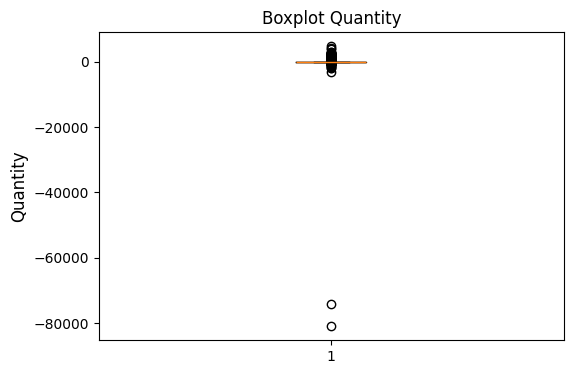

In [44]:
#Mengecek outliers menggunakan boxplot
plt.figure(figsize=(6,4))
plt.boxplot(df['quantity'])
plt.title('Boxplot Quantity',fontsize=12)
plt.ylabel('Quantity',fontsize=12)
plt.show()

In [45]:
df_outliers_ekstrem = df[df['quantity'] > 70000]
kolom_analisis = ['invoice_code', 'stock_code', 'description', 'quantity', 'price_rupiah', 'revenue', 'customer_id', 'date']
display(df_outliers_ekstrem[kolom_analisis])

,invoice_code,stock_code,description,quantity,price_rupiah,revenue,customer_id,date


#Feature Engineering

##Price Rupiah

In [46]:
# Mengalikan kolom price dengan 8790 untuk membuat kolom price_rupiah
df['price_rupiah'] = df['price'] * 8790

print("✅ Sukses membuat kolom price_rupiah.")

# Menampilkan kolom terkait untuk memastikan perhitungan matematika sudah benar
print("\n🔍 Sampel Perbandingan Nilai Kolom Price dan Price_Rupiah:")
display(df[['price', 'price_rupiah']].head())

✅ Sukses membuat kolom price_rupiah.

🔍 Sampel Perbandingan Nilai Kolom Price dan Price_Rupiah:


,price,price_rupiah
0,2.55,22414.5
1,3.39,29798.1
2,2.75,24172.5
3,3.39,29798.1
4,3.39,29798.1


##Date, Month, Year, Day of Week, Is Weekend, Hour Transaction

In [47]:
df["month"] = df["order_date"].dt.month
df["date"] = df["order_date"].dt.day
df["year"] = df["order_date"].dt.year
df["day_of_week"] = df["order_date"].dt.dayofweek
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
df["hour_transaction"] = df["order_date"].dt.hour

In [48]:
df[[
    "order_date",
    "month",
    "date",
    "year",
    "day_of_week",
    "is_weekend",
    "hour_transaction"
]].head()

,order_date,month,date,year,day_of_week,is_weekend,hour_transaction
0,2010-12-01 08:26:00,12,1,2010,2,0,8
1,2010-12-01 08:26:00,12,1,2010,2,0,8
2,2010-12-01 08:26:00,12,1,2010,2,0,8
3,2010-12-01 08:26:00,12,1,2010,2,0,8
4,2010-12-01 08:26:00,12,1,2010,2,0,8


##Revenue

In [49]:
df['revenue'] = df['price_rupiah'] * df['quantity']

In [50]:
df['revenue'].head()

,revenue
0,134487.0
1,178788.6
2,193380.0
3,178788.6
4,178788.6


##Quantity Category

In [51]:
# Tentukan batas angka (bins) untuk setiap kategori
# Batas: 0-10 (Small), 11-50 (Medium), 51-500 (Large), 501 ke atas hingga tak terhingga (Wholesaler)
batas_angka = [0, 10, 50, 500, float('inf')]

# Tentukan label teks untuk masing-masing kelompok tersebut
label_kategori = ['Small', 'Medium', 'Large', 'Wholesaler']

# Isi kolom quantity_category menggunakan fungsi pd.cut()
# Parameter errors='coerce' atau mengabaikan nilai negatif dulu agar tidak error saat pemotongan angka
df['quantity_category'] = pd.cut(df['quantity'], bins=batas_angka, labels=label_kategori)

# Opsional: Transaksi pembatalan/retur (quantity < 0) diberi label khusus 'Canceled/Return'
df['quantity_category'] = df['quantity_category'].astype(str) # Ubah ke string agar bisa ditambahkan kategori baru
df.loc[df['quantity'] < 0, 'quantity_category'] = 'Canceled/Return'

# Menghitung berapa banyak transaksi yang masuk ke tiap-tiap kategori
print("\n📊 Distribusi Jumlah Transaksi per Kategori:")
print(df['quantity_category'].value_counts())

# Menampilkan sampel acak untuk melihat hasil pemetaan
print("\n🔍 Sampel Hasil Pengelompokan:")
display(df[['quantity', 'quantity_category']].sample(10, random_state=42))


📊 Distribusi Jumlah Transaksi per Kategori:
quantity_category
Small              385225
Medium             118284
Large               11313
Canceled/Return      3305
Wholesaler            378
Name: count, dtype: int64

🔍 Sampel Hasil Pengelompokan:


,quantity,quantity_category
412348,2,Small
295810,2,Small
14856,4,Small
284437,1440,Wholesaler
296787,1,Small
468640,2,Small
291131,2,Small
416595,3,Small
165540,24,Medium
35428,1,Small


##Rename Description

In [52]:
df = df.rename(columns={'description': 'nama_produk'})

In [53]:
df

,invoice_code,stock_code,nama_produk,quantity,order_date,price,unit,customer_id,country,price_rupiah,...,month,year,revenue,day_of_week,is_weekend,hour_transaction,quantity_category,segment_rfm,basket_size,product_category
0,536365,90220,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,dollar,17850,United Kingdom,22414.5,...,12,2010,134487.0,2,0,8,Small,NaN,NaN,NaN
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,dollar,17850,United Kingdom,29798.1,...,12,2010,178788.6,2,0,8,Small,NaN,NaN,NaN
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,dollar,17850,United Kingdom,24172.5,...,12,2010,193380.0,2,0,8,Small,NaN,NaN,NaN
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,dollar,17850,United Kingdom,29798.1,...,12,2010,178788.6,2,0,8,Small,NaN,NaN,NaN
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART,6,2010-12-01 08:26:00,3.39,dollar,17850,United Kingdom,29798.1,...,12,2010,178788.6,2,0,8,Small,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,dollar,12680,France,7471.5,...,12,2011,89658.0,4,0,12,Medium,NaN,NaN,NaN
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,dollar,12680,France,18459.0,...,12,2011,110754.0,4,0,12,Small,NaN,NaN,NaN
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,dollar,12680,France,36478.5,...,12,2011,145914.0,4,0,12,Small,NaN,NaN,NaN
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,dollar,12680,France,36478.5,...,12,2011,145914.0,4,0,12,Small,NaN,NaN,NaN


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 518505 entries, 0 to 541908
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   invoice_code       518505 non-null  object        
 1   stock_code         518505 non-null  object        
 2   nama_produk        518505 non-null  object        
 3   quantity           518505 non-null  int64         
 4   order_date         518505 non-null  datetime64[ns]
 5   price              518505 non-null  float64       
 6   unit               518505 non-null  object        
 7   customer_id        518505 non-null  int64         
 8   country            518505 non-null  object        
 9   price_rupiah       518505 non-null  float64       
 10  date               518505 non-null  int32         
 11  month              518505 non-null  int32         
 12  year               518505 non-null  int32         
 13  revenue            518505 non-null  float64      

#Mengimport Data yang Sudah Di-Cleaning ke SQL

In [55]:
#Mengimport data setelah di cleaning ke SQL
df.to_sql('online_retail', con=engine, schema='public', if_exists='replace', index=False)

505

In [56]:
df.to_excel('online_retail.xlsx')